## Closing the water balance using remote sensing data

*ENVM1502* - March 2026

Different datasets were downloaded and used to close the water balance and do Kalman Filtering and smoothing. 

In [68]:
import warnings
warnings.filterwarnings('ignore')

In [69]:
# useful imports
# useful imports
from scipy.stats import norm#the normal distribution
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

# Part 1: Errors in water balance data

#### Precipitation data

Three precipitation time-series used are: `manning_imerg_precip_hourly` (precipitation from [GPM IMERG](https://developers.google.com/earth-engine/datasets/catalog/NASA_GPM_L3_IMERG_V07)), `manning_ERA5_precip_daily` (precipitation from [ERA5](https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_LAND_DAILY_AGGR)), `manning_chirps_precip_daily` (precipitation from [CHIRPS](https://developers.google.com/earth-engine/datasets/catalog/UCSB-CHG_CHIRPS_DAILY)).

,precipitation
date,
1998-01-01,0.002322
1998-01-02,0.052921
1998-01-03,13.451363
1998-01-04,1.750016
1998-01-05,14.733206


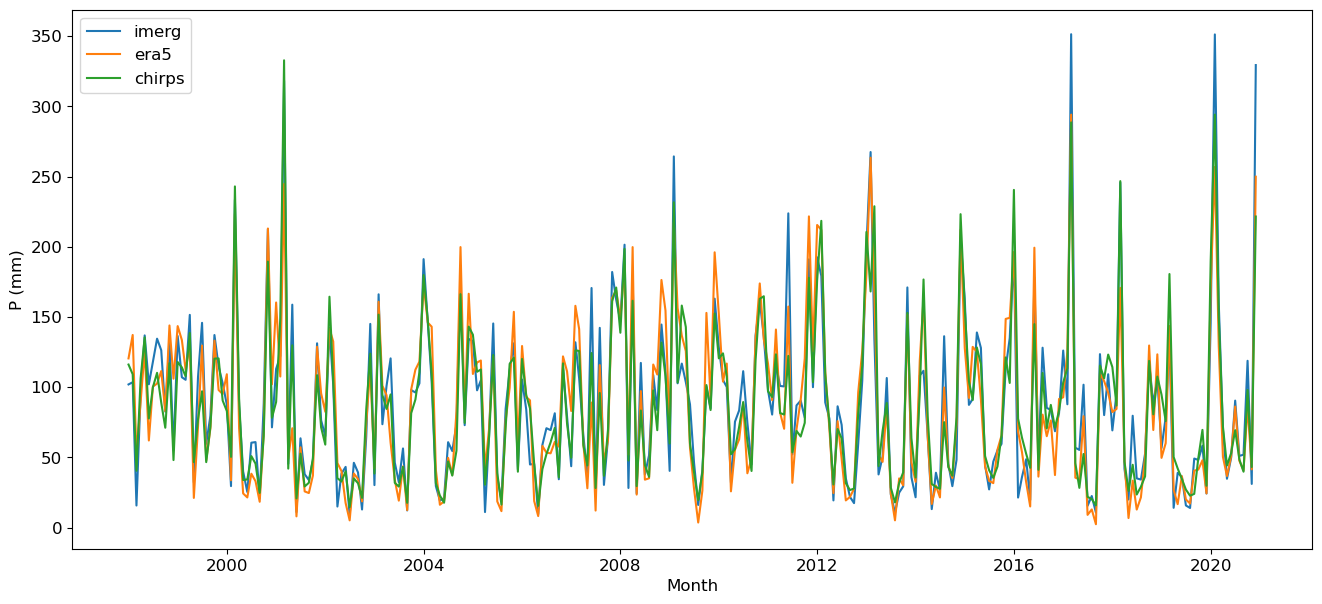

In [70]:
era5P = pd.read_csv('./Data/manning_ERA5_precip_daily.csv') # m/day 
chirps = pd.read_csv('./Data/manning_chirps_precip_daily.csv') # mm/day
imerg = pd.read_csv('./Data/manning_imerg_precip_hourly.csv') # mm/hr


era5P['date'] = pd.to_datetime(era5P['system:index'], format='%Y%m%d')
era5P.set_index('date', inplace=True)
era5P.drop(columns=['system:index'], inplace=True)
era5P['total_precipitation_sum'] = era5P['total_precipitation_sum'] * 1000 # mm/day
era5P_monthly = era5P.resample('MS').sum() # mm/month
era5P.head()


chirps['date'] = pd.to_datetime(chirps['system:index'], format='%Y%m%d')
chirps.set_index('date', inplace=True)
chirps.drop(columns=['system:index'], inplace=True)
chirps_monthly = chirps.resample('MS').sum() # mm/month
chirps.head()   

imerg['date'] = pd.to_datetime(imerg['system:index'], format='%Y%m%d%H%M%S')
imerg.set_index('date', inplace=True)
imerg.drop(columns=['system:index'], inplace=True)
imerg = imerg.resample('D').sum() / 2 # mm/day
imerg_monthly = imerg.resample('MS').sum() # mm/month

start_date = '1998-01-01'
end_date = '2020-12-31'

imerg_monthly = imerg_monthly.loc[start_date:end_date]
era5P_monthly = era5P_monthly.loc[start_date:end_date]
chirps_monthly = chirps_monthly.loc[start_date:end_date]


plt.figure(figsize=(16,7))
plt.plot(imerg_monthly['precipitation'], label='imerg')
plt.plot(era5P_monthly['total_precipitation_sum'], label='era5')
plt.plot(chirps_monthly['precipitation'], label='chirps')
plt.legend()
plt.xlabel('Month') 
plt.ylabel('P (mm)');
plt.rcParams["font.size"] = 12

imerg.head()


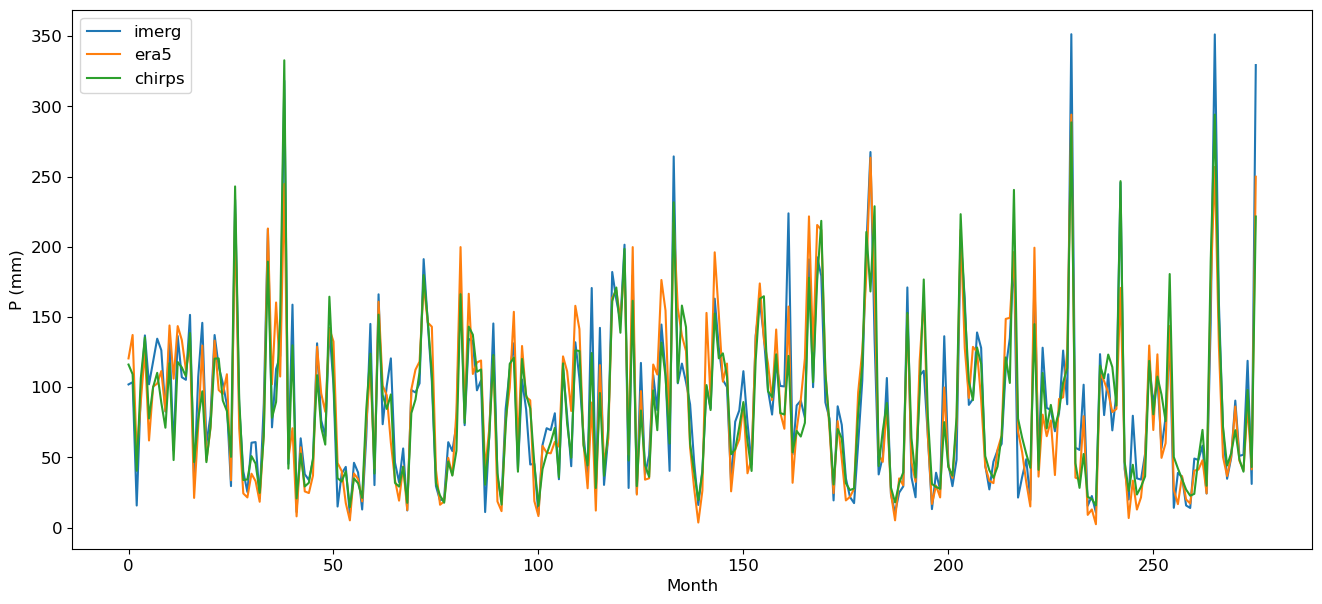

In [71]:
# Read and plot the monthly precipitation data
PObs1 = imerg_monthly['precipitation'].values
PObs2 = era5P_monthly['total_precipitation_sum'].values
PObs3 = chirps_monthly['precipitation'].values
plt.figure(figsize=(16,7))
plt.plot(PObs1, label='imerg')
plt.plot(PObs2, label='era5')
plt.plot(PObs3, label='chirps')
plt.legend()
plt.xlabel('Month')
plt.ylabel('P (mm)');
plt.rcParams["font.size"] = 12


In each month, the sample mean $m$ and variance $v$ across $N$ datasets can be computed as:

$$m = \frac{1}{N}\sum_{i=1}^N x_i$$
$$v = \frac{1}{N-1}\sum_{i=1}^N (x_i - m)^2$$

If we apply these equations to the three precipitation datasets, we get monthly values of $m_P$ and $v_P$, which we interpret as mean and variance of a normal (Gaussian) distribution $\mathcal{N}(P|m_P, v_P)$ for the precipitation errors (uncertainty) in each month.

In [72]:
# Compute monthly mean mP and variance vP of precipitation
PObs1 = imerg_monthly['precipitation']
PObs2 = era5P_monthly['total_precipitation_sum']
PObs3 = chirps_monthly['precipitation']

mP = (PObs1 + PObs2 + PObs3) / 3
vP = (np.square(PObs1 - mP) + np.square(PObs2 - mP) + np.square(PObs3 - mP)) / 2
print(mP[0], vP[0])


112.82940165845662 93.8406862407328


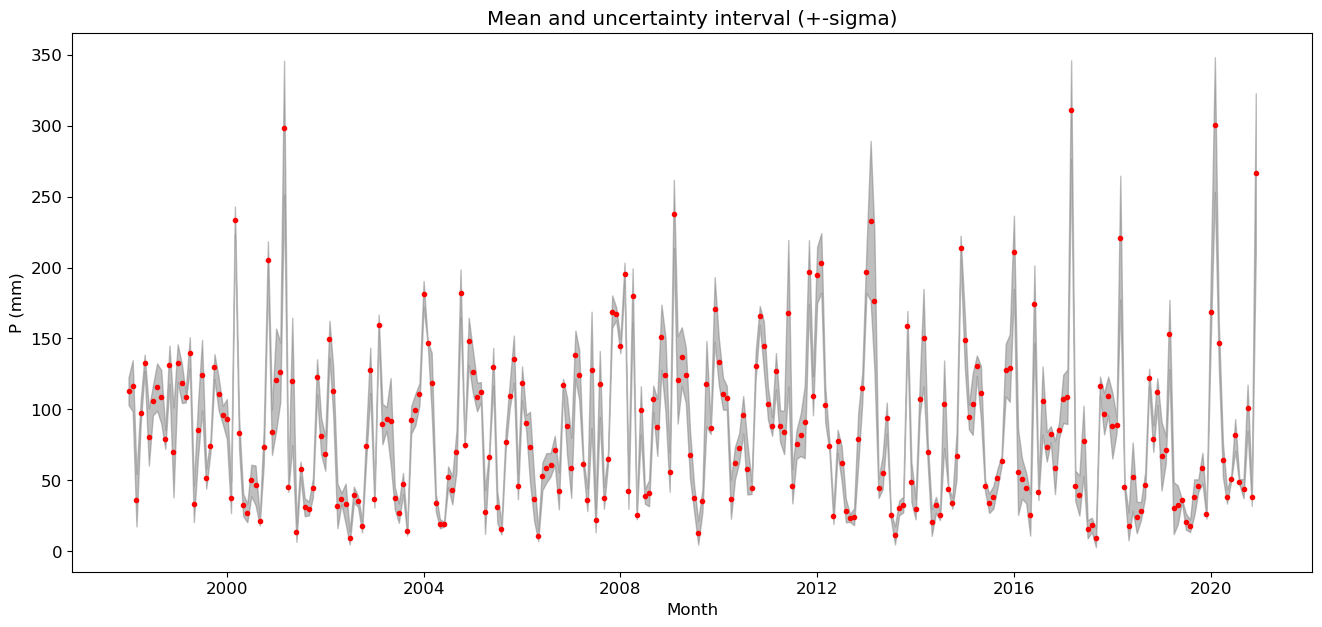

In [73]:
# Plot monthly mean and uncertainty interval (+-sigma) of precipitation.
# The plt.fill_between() function is useful for plotting an uncertainty interval.
# Plot monthly mean and uncertainty interval (+-sigma) of precipitation.
# The plt.fill_between() function is useful for plotting an uncertainty interval.
plt.figure(figsize=(16,7))
plt.fill_between(imerg_monthly.index, mP - np.sqrt(vP), mP + np.sqrt(vP), color='grey', alpha=0.5)
plt.plot(mP, 'r.')
plt.xlabel('Month')
plt.ylabel('P (mm)')
plt.title('Mean and uncertainty interval (+-sigma)');

#### Evaporation data

Four evaporation time-series are used: `manning_gldas_evap_3hour` (actual evaporation from [GLDAS](https://developers.google.com/earth-engine/datasets/catalog/NASA_GLDAS_V021_NOAH_G025_T3H)), `manning_ERA5_evap_daily` (actual evaporation from [ERA5](https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_LAND_MONTHLY_AGGR)), `manning_mod16_evap_8day` (actual evaporation from [MODIS](https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD16A2GF)), `manning_CMRSETlandsat_evap_monthly` (actual evaporation from [CMRSET Landsat](https://developers.google.com/earth-engine/datasets/catalog/TERN_AET_CMRSET_LANDSAT_V2_2)).

In [74]:
# Loading the data
gldas = pd.read_csv('./Data/manning_gldas_evap_3hour.csv') # mm/s
era5E = pd.read_csv('./Data/manning_ERA5_evap_daily.csv') # m/day
mod16 = pd.read_csv('./Data/manning_mod16_evap_8day.csv') # 0.1 mm/8days
CMRSET = pd.read_csv('./Data/manning_CMRSETlandsat_evap_monthly.csv') # mm/month

# Setting the units to mm/month
gldas['date'] = pd.to_datetime(gldas['system:index'], format='A%Y%m%d_%H%M')
gldas.set_index('date', inplace=True)
gldas.drop(columns=['system:index'], inplace=True)
gldas['Evap_tavg'] = gldas['Evap_tavg'] * 10800 # mm/3hr
gldas = gldas.resample('D').sum() # mm/day
gldas_monthly = gldas.resample('MS').sum() # mm/month

era5E['date'] = pd.to_datetime(era5E['system:index'], format='%Y%m%d')
era5E.set_index('date', inplace=True)
era5E.drop(columns=['system:index'], inplace=True)
era5E['total_evaporation_sum'] = era5E['total_evaporation_sum'] * -1000 # mm/day
era5E_monthly = era5E.resample('MS').sum() # mm/month

mod16['date'] = pd.to_datetime(mod16['system:index'], format='%Y_%m_%d')
mod16.set_index('date', inplace=True)
mod16.drop(columns=['system:index'], inplace=True)
mod16['ET'] = mod16['ET'] * 0.1 # mm/8days
mod16_monthly = mod16.resample('MS').sum() # mm/month

CMRSET['date'] = pd.to_datetime(CMRSET['system:index'], format='%Y_%m_%d')
CMRSET.set_index('date', inplace=True)
CMRSET.drop(columns=['system:index'], inplace=True)
CMRSET['ETa_monthly'] = CMRSET['ETa'] * CMRSET.index.days_in_month

CMRSET_monthly = CMRSET.copy()



                 ETa  ETa_monthly
date                             
1987-05-01  1.398698    43.359652
1987-06-01  1.067470    32.024108
1987-07-01  1.249994    38.749811
1987-08-01  2.332874    72.319099
1987-09-01  2.472461    74.173820


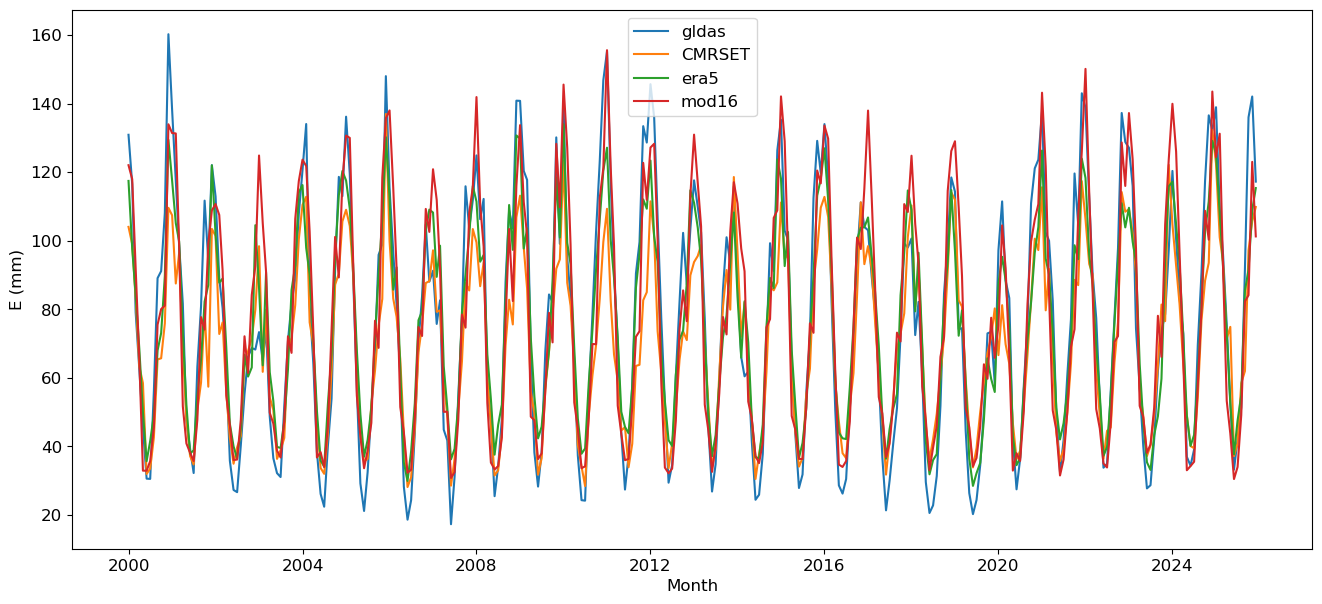

In [75]:
# Plotting the data
start_date = '2000-01-01'
end_date = '2025-12-31'

gldas_plot = gldas_monthly.loc[start_date:end_date]
era5E_plot = era5E_monthly.loc[start_date:end_date]
mod16_plot = mod16_monthly.loc[start_date:end_date]
CMRSET_plot = CMRSET_monthly.loc[start_date:end_date]
plt.figure(figsize=(16,7))
plt.plot(gldas_plot['Evap_tavg'], label='gldas')
plt.plot(CMRSET_plot['ETa_monthly'], label='CMRSET')
plt.plot(era5E_plot['total_evaporation_sum'], label='era5')
plt.plot(mod16_plot['ET'], label='mod16')

plt.legend()
plt.xlabel('Month')
plt.ylabel('E (mm)');
plt.rcParams["font.size"] = 12
print(CMRSET.head())

In [76]:
# Compute monthly mean mE and variance vE of evaporation
EObs1 = gldas_monthly['Evap_tavg']
EObs2 = era5E_monthly['total_evaporation_sum']
EObs3 = mod16_monthly['ET']
EObs4 = CMRSET_monthly['ETa_monthly']
print(EObs1[0], EObs2[0], EObs3[0], EObs4[0])
mE = (EObs1 + EObs2 + EObs3 + EObs4) / 4
vE = (np.square(EObs1 - mE) + np.square(EObs2 - mE) + np.square(EObs3 - mE) + np.square(EObs4 - mE)) / 4


130.89575147889173 92.3967701118065 122.01926616398504 43.3596519863821


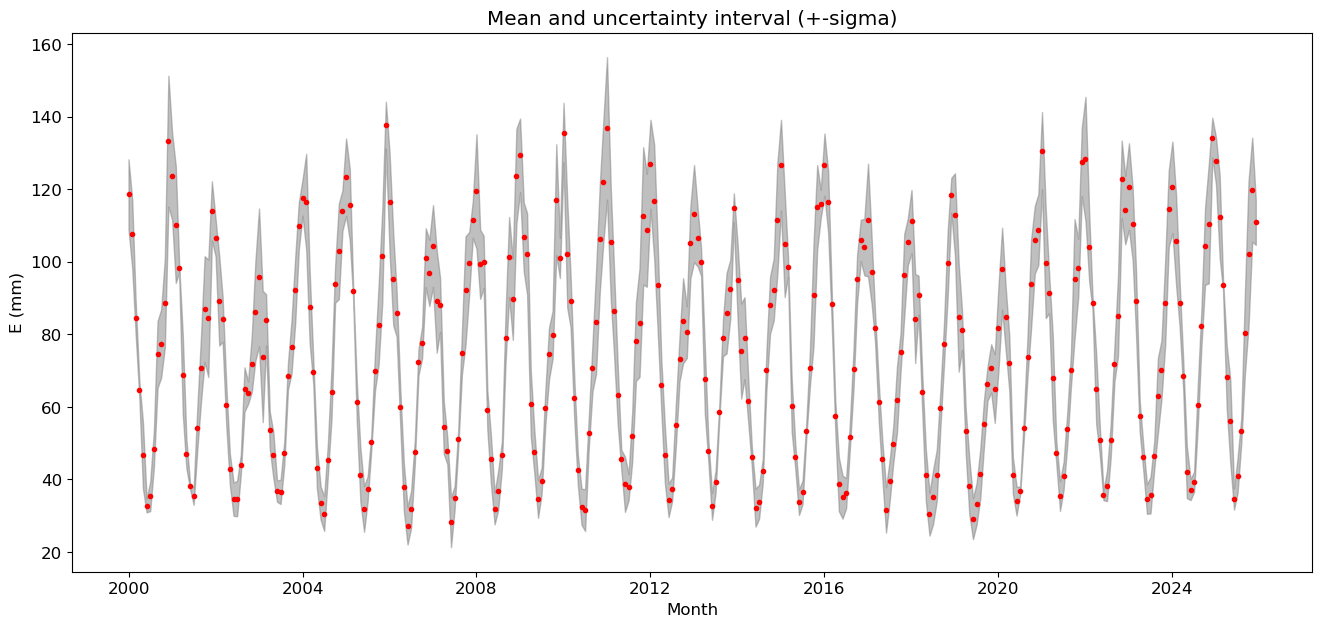

In [77]:
# Plot monthly mean and uncertainty interval (+-sigma) of evaporation
plt.figure(figsize=(16,7))
plt.fill_between(mE.index, mE - np.sqrt(vE), mE + np.sqrt(vE), color='grey', alpha=0.5)
plt.plot(mE, 'r.')
plt.xlabel('Month')
plt.ylabel('E (mm)')
plt.title('Mean and uncertainty interval (+-sigma)');


#### River discharge data

The file `5202080_Q_Day.Cmd.txt`contains daily river discharge from a stream gauge at the river basin from GRDC. The station is Killawara. The catchment size is 6642 km^2.

date
2000-01-01    13.981073
2000-02-01     6.303623
2000-03-01    46.075239
2000-04-01    19.993782
2000-05-01    14.965164
Freq: MS, Name: Q, dtype: float64


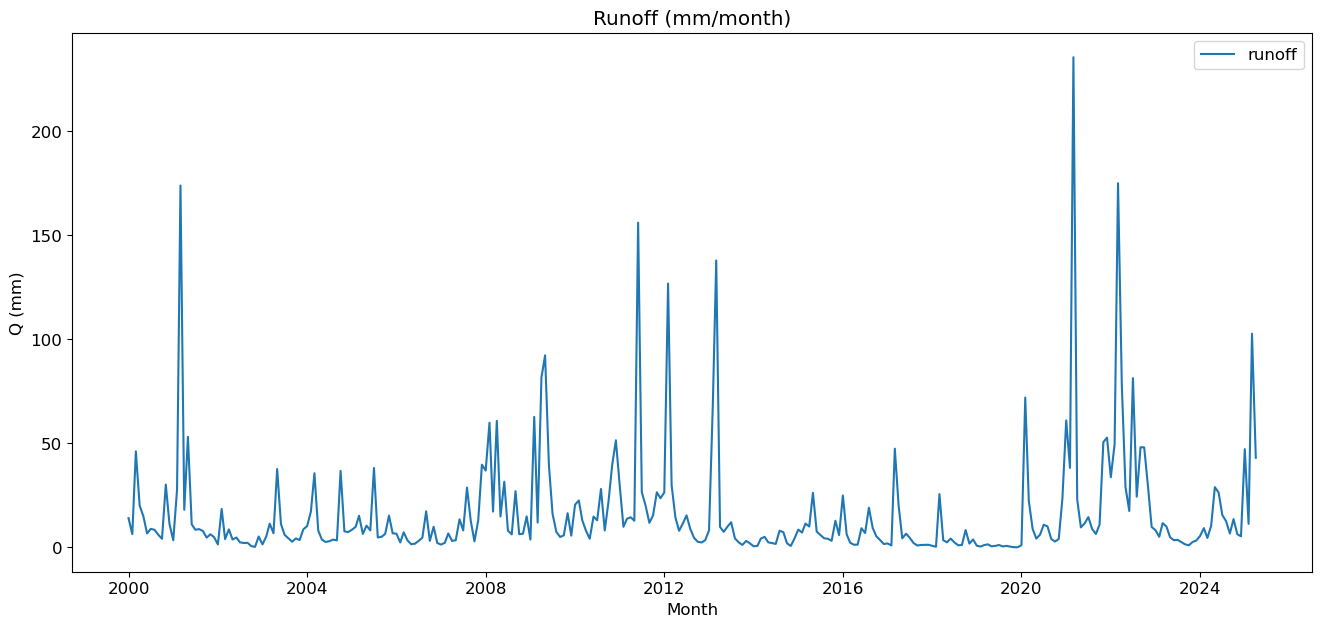

In [ ]:
A_catchment = 6642 * 1e6   # m2


# Dischrarge data Killawarra station (GRDC ID: 5202080)
obs =  pd.read_csv("./Data/5202080_Q_Day.Cmd.txt",delimiter=';',skiprows=36,header=0,encoding='cp1252')
obs.columns = ['date', 'time', 'Q']
obs['date'] = pd.to_datetime(obs['date'], format='%Y-%m-%d')
obs['Q'] = pd.to_numeric(obs['Q'], errors='coerce')
obs = obs[obs['Q'] != -999]
obs.set_index('date', inplace=True)
obs.drop(columns=['time'], inplace=True)


# m3/s -> mm/day
obs['Q'] = obs['Q'] * 86400 / A_catchment * 1000
obs = obs.loc['2000-01-01':'2025-12-31']
obs_monthly = obs.resample('MS').sum() # mm/month 

QObs = obs_monthly['Q']
plt.figure(figsize=(16,7))
plt.plot(QObs, label='runoff')
plt.legend()
plt.xlabel('Month')
plt.ylabel('Q (mm)')
plt.title('Runoff (mm/month)');



Uncertainty and errors in river discharge measurements can in principle be estimated using a rating curve error analysis. Here, we will assume a 10% relative error in each month, reflecting the common situation of greater errors for measuring larger flow rates. This assumption allows us to compute a Gaussian distribution $\mathcal{N}(Q|m_Q, v_Q)$ for river discharge uncertainty in each month, where $m_Q$ is equal to the discharge measurement (unbiased measurement) and $v_Q$ is computed from the 10% error assumption.

In [138]:
# Compute monthly mean mQ and variance vQ of river discharge
mQ = QObs
vQ = np.square(0.1 * QObs)
print(mQ[0], vQ[0])


13.981073170731706 1.9547040700535399


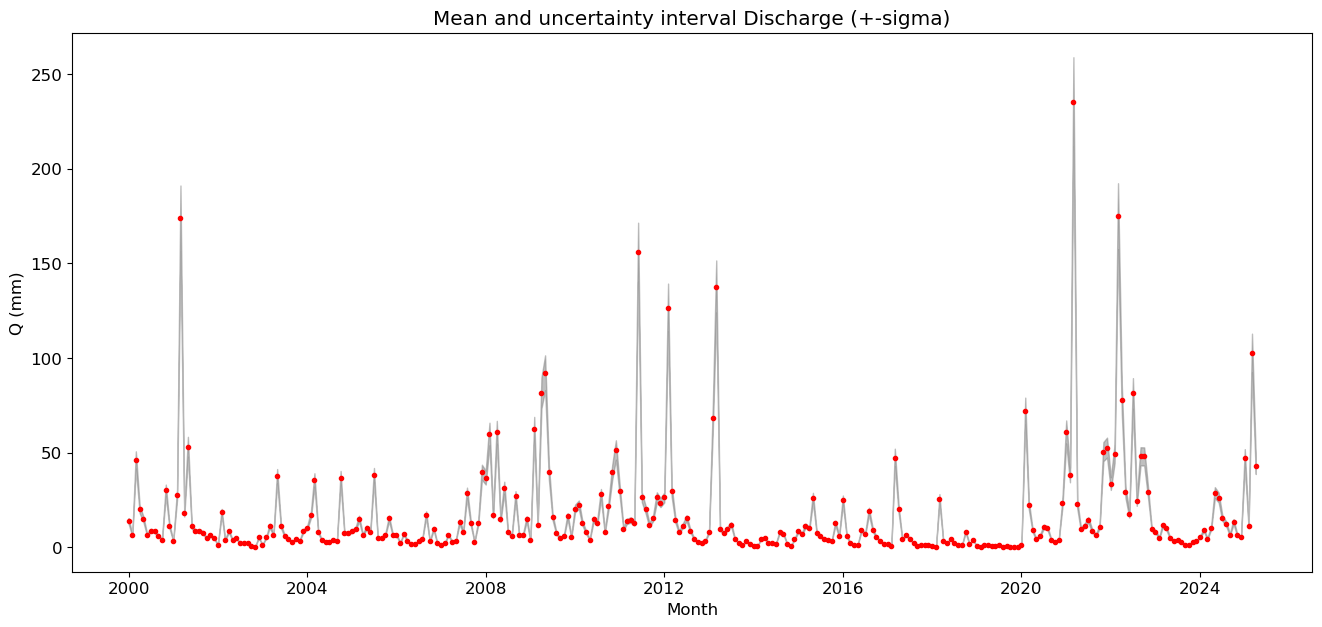

In [139]:
# Plot monthly mean and uncertainty interval (+-sigma) of river discharge
plt.figure(figsize=(16,7))
plt.fill_between(obs_monthly.index, mQ - np.sqrt(vQ), mQ + np.sqrt(vQ), color='grey', alpha=0.5)
plt.plot(mQ, 'r.')
plt.xlabel('Month')
plt.ylabel('Q (mm)')
plt.title('Mean and uncertainty interval Discharge (+-sigma)');

#### Water storage data

Monthly time-series of total water storage is provided in file `manning_grace_storage_monthly` (total water storage from the [GRACE](https://developers.google.com/earth-engine/datasets/catalog/NASA/GRACE/MASS_GRIDS_V04/LAND) dataset). This dataset also comes with an estimate of the standard error (square root of error variance) in the monthly data, provided in file `manning_grace_error_monthly` (standard error of the GRACE data). Note that the GRACE data include months with missing data; these are indicated with a nodata value of -99999. 

<Figure size 1600x700 with 0 Axes>

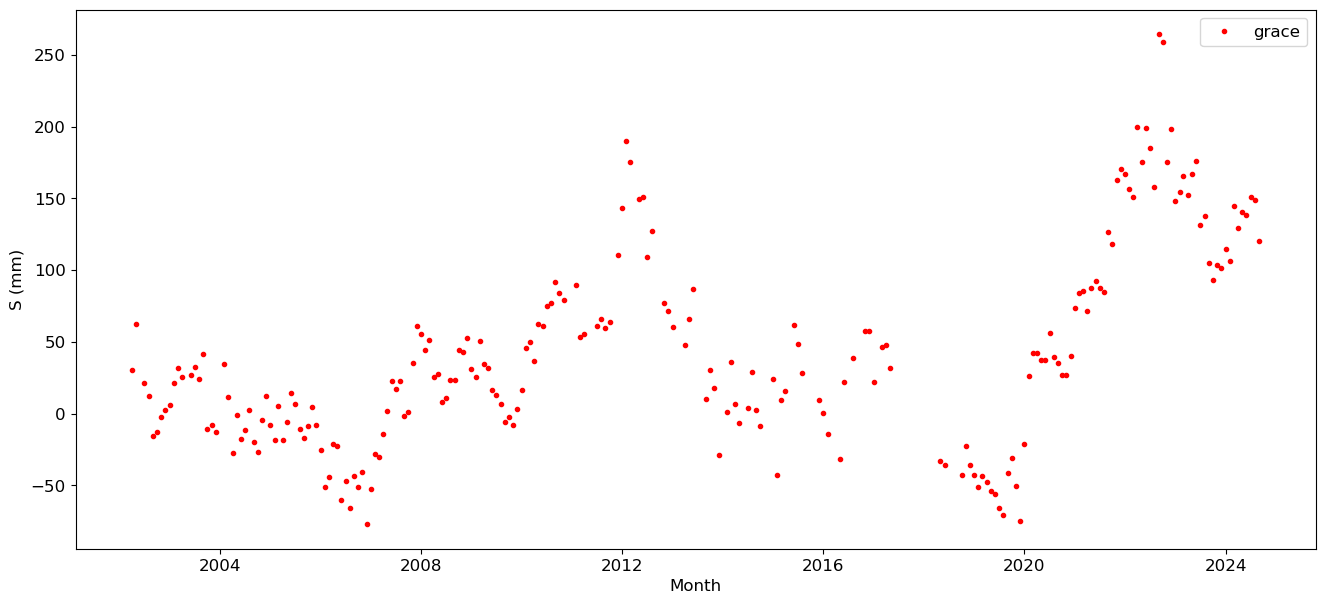

In [81]:
# Read and plot the Data/monthly storage data
grace = pd.read_csv('./Data/manning_grace_storage_monthly.csv') # cm
grace_error = pd.read_csv('./Data/manning_grace_error_monthly.csv') # cm
# Seting the units to mm
grace['date'] = pd.to_datetime(grace['system:index'].str.split('_').str[0], format='%Y%m%d')
grace.set_index('date', inplace=True)
grace.drop(columns=['system:index'], inplace=True)
grace['lwe_thickness'] = grace['lwe_thickness'] * 10 # mm
full_date_range = pd.date_range(start=era5P.index.min(), end=era5P.index.max(), freq='D')
grace = grace.reindex(full_date_range, fill_value=pd.NA)
grace = grace.resample('MS').mean()

grace_error['date'] = pd.to_datetime(grace_error['system:index'].str.split('_').str[0], format='%Y%m%d')
grace_error.set_index('date', inplace=True)
grace_error.drop(columns=['system:index'], inplace=True)
grace_error['uncertainty'] = grace_error['uncertainty']  * 10 # mm
grace_error = grace_error.reindex(full_date_range, fill_value=pd.NA)
grace_error = grace_error.resample('MS').mean()
plt.figure(figsize=(16,7))

SObs = grace['lwe_thickness']
sigmaSObs = grace_error['uncertainty']
plt.figure(figsize=(16,7))
plt.plot(SObs, 'r.', label='grace')
plt.legend()
plt.xlabel('Month')
plt.ylabel('S (mm)');



Since the GRACE dataset come with its own estimate of data error we will use it directly to get a Gaussian distribution $\mathcal{N}(S|m_S, v_S)$ for the uncertainty in water storage in each month. Here, $m_S$ is taken as the GRACE measurement and $v_S$ is set to the square of the GRACE standard error.

*Hint: to handle missing data values in the GRACE time-series you can for example set $m_S = 0$ and $v_S = 10^9$ (some large variance). Using a large variance represents a data value with extreme uncertainty, which is essentially equivalent to having no data for that month.*

In [99]:
# Compute monthly mean mS and variance vS of water storage
mS = SObs
vS = np.square(sigmaSObs)
nodata = (SObs == -99999)
mS[nodata] = np.nan   # use nan for plotting
vS[nodata] = np.nan

print(mS.iloc[0], vS.iloc[0])


nan nan


<Figure size 1600x700 with 0 Axes>

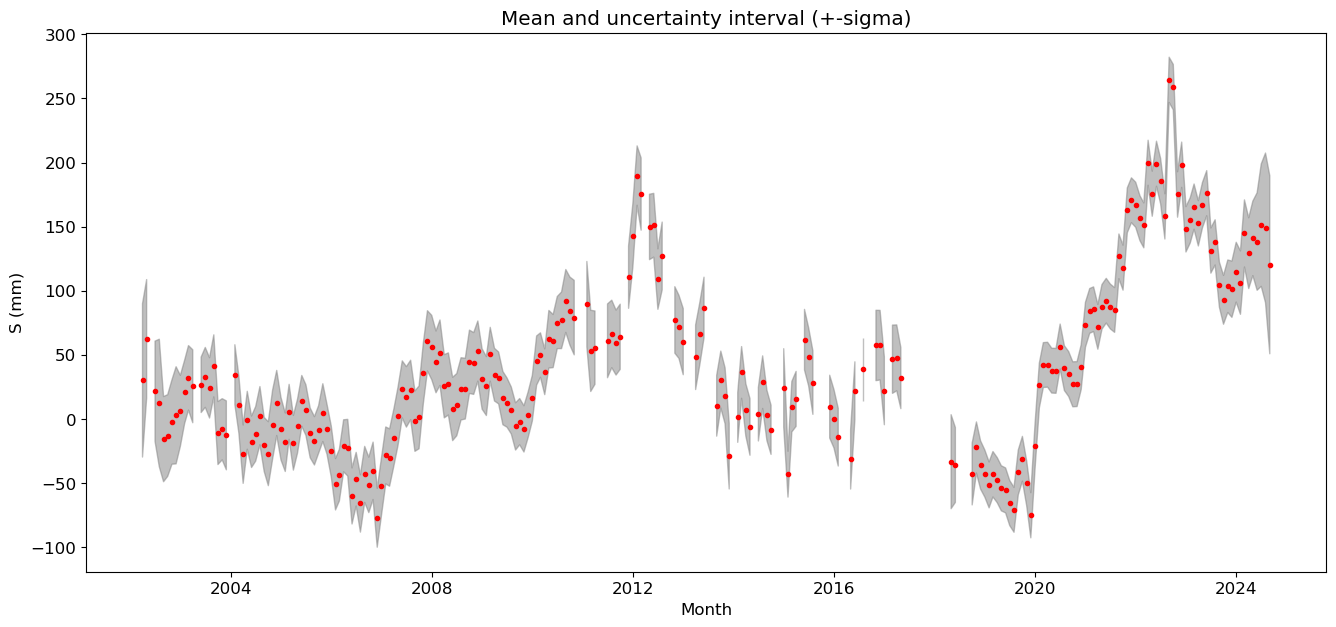

In [100]:
# Plot monthly mean and uncertainty interval (+-sigma) of water storage
plt.figure(figsize=(16,7))
plt.figure(figsize=(16,7))
x = mS.index
plt.fill_between(x,mS - np.sqrt(vS),mS + np.sqrt(vS),color='grey',alpha=0.5)
plt.plot(x, mS, 'r.')
plt.xlabel('Month')
plt.ylabel('S (mm)')
plt.title('Mean and uncertainty interval (+-sigma)')
# 
SObs = SObs.copy()
mS[nodata] = 0
# vS[nodata] = 1e+9


# Part 2: Uncertainty propagation and Gaussian product 

In [84]:
# mP = 40.5
# vP = 10.2
# mE = 20.3
# vE = 10.9
# mQ = 5.3
# vQ = 0.5
# mS0 = 100
# vS0 = 100
# mS = 100
# vS = 100
# # 1) Propagate uncertainty to S
# # Water balance: S = S0 + P - E - Q
# mToS = mS0 + mP - mE - mQ
# vToS = vS0 + vP + vE + vQ
# print("Result for S from water balance:")
# print("mS =", mToS)
# print("vS =", vToS)
# # 2) Propagate uncertainty to P
# # Rewrite water balance:
# # P = S - S0 + E + Q
# mToP = mS - mS0 + mE + mQ
# vToP = vS + vS0 + vE + vQ
# print("\nResult for P from water balance:")
# print("mP =", mToP)
# print("vP =", vToP)

In [101]:
def gaussian_product(m1, v1, m2, v2):
    # weights
    w1 = v2 / (v1 + v2)
    w2 = v1 / (v1 + v2)  
    # new mean
    m = w1 * m1 + w2 * m2   
    # new variance
    v = (v1 * v2) / (v1 + v2)  
    return m, v

gaussian_product(10.2, 2, 5.6, 1)


(7.133333333333333, 0.6666666666666666)

In [105]:
mP = np.asarray(mP)
mE = np.asarray(mE)
mQ = np.asarray(mQ)
mS = np.asarray(mS)

vP = np.asarray(vP)
vE = np.asarray(vE)
vQ = np.asarray(vQ)
vS = np.asarray(vS)

print(type(mP), mP.shape)
print(type(mE), mE.shape)
print(type(mQ), mQ.shape)
print(type(mS), mS.shape)

print(type(vP), vP.shape)
print(type(vE), vE.shape)
print(type(vQ), vQ.shape)
print(type(vS), vS.shape)



<class 'numpy.ndarray'> (276,)
<class 'numpy.ndarray'> (540,)
<class 'numpy.ndarray'> (959,)
<class 'numpy.ndarray'> (540,)
<class 'numpy.ndarray'> (276,)
<class 'numpy.ndarray'> (540,)
<class 'numpy.ndarray'> (959,)
<class 'numpy.ndarray'> (540,)


# Part 3: Kalman filtering and smoothing

In [106]:
def close_water_balance(mP, vP, mE, vE, mQ, vQ, mS, vS):
    # Specify prior mean and variance for initial storage S0 (first month)
    mS0 = 0
    vS0 = 200 * 200#large variance to indicate large uncertainty
        
    # Initialize posteriors
    # We compute these in forward loop (filtering posteriors) and then update them in backward loop (smoothing posteriors)
    nt = len(mP)#number of months in time-series
    mPostP = np.zeros(nt)#posterior mean of precipitation in each month
    vPostP = np.zeros(nt)#posterior variance of precipitation in each month
    mPostE = np.zeros(nt)#etc...
    vPostE = np.zeros(nt)
    mPostQ = np.zeros(nt)
    vPostQ = np.zeros(nt)
    mPostS = np.zeros(nt)
    vPostS = np.zeros(nt)
    
    # Forward loop (filtering)
    for t in range(nt):
        # Step 1: predict - compute forward distribution to S
        if t == 0:
            mFromS = mS0
            vFromS = vS0
        else: 
            mFromS = mPostS[t-1]
            vFromS = vPostS[t-1]
        mToS = mFromS + mP[t] - mE[t] - mQ[t]
        vToS = vFromS + vP[t] + vE[t] + vQ[t]
        
        # Step 2: update - compute filtering posterior of S

        mPostS[t], vPostS[t] = gaussian_product(mToS, vToS, mS[t], vS[t])


    # Backward loop (smoothing)
    mToS, vToS = 0.0, 1e+9 #represents backward distribution to S - initialize to wide Gaussian for last month
    for t in reversed(range(nt)):
        # Step 1: smoothing posterior of S

        mPostS[t], vPostS[t] = gaussian_product(mPostS[t], vPostS[t], mToS, vToS)
        if t == 0:
            mFromS = mS0
            vFromS = vS0
        else:
            mFromS = mPostS[t-1] 
            vFromS = vPostS[t-1]
        # Step 2: posteriors of P, E, and Q
     
        mFromS, vFromS = gaussian_product(mToS, vToS, mS[t], vS[t])
        if t == 0:
            mFromS0, vFromS0 = mS0, vS0
        else:
            mFromS0, vFromS0 = mPostS[t-1], vPostS[t-1]
        mdiff = mFromS0 - mFromS
        vdiff = vFromS0 + vFromS
        mPostP[t], vPostP[t] = gaussian_product(-mdiff + mE[t] + mQ[t], vdiff + vE[t] + vQ[t], mP[t], vP[t])
        mPostE[t], vPostE[t] = gaussian_product(mdiff + mP[t] - mQ[t], vdiff + vP[t] + vQ[t], mE[t], vE[t])
        mPostQ[t], vPostQ[t] = gaussian_product(mdiff + mP[t] - mE[t], vdiff + vP[t] + vE[t], mQ[t], vQ[t])
        
        # Step 3: backward distribution to S0
        
        mToS = mFromS - mP[t] + mE[t] + mQ[t]
        vToS = vFromS + vP[t] + vE[t] + vQ[t]
        
    # After backward loop: compute posterior mean and variance of S0 (initial storage first month)
   
    mPostS0, vPostS0 = gaussian_product(mS0, vS0, mToS, vToS)
    
    # Return final water balance estimates (posterior means and variances of monthly estimates)
    return mPostP, vPostP, mPostE, vPostE, mPostQ, vPostQ, mPostS, vPostS, mPostS0, vPostS0


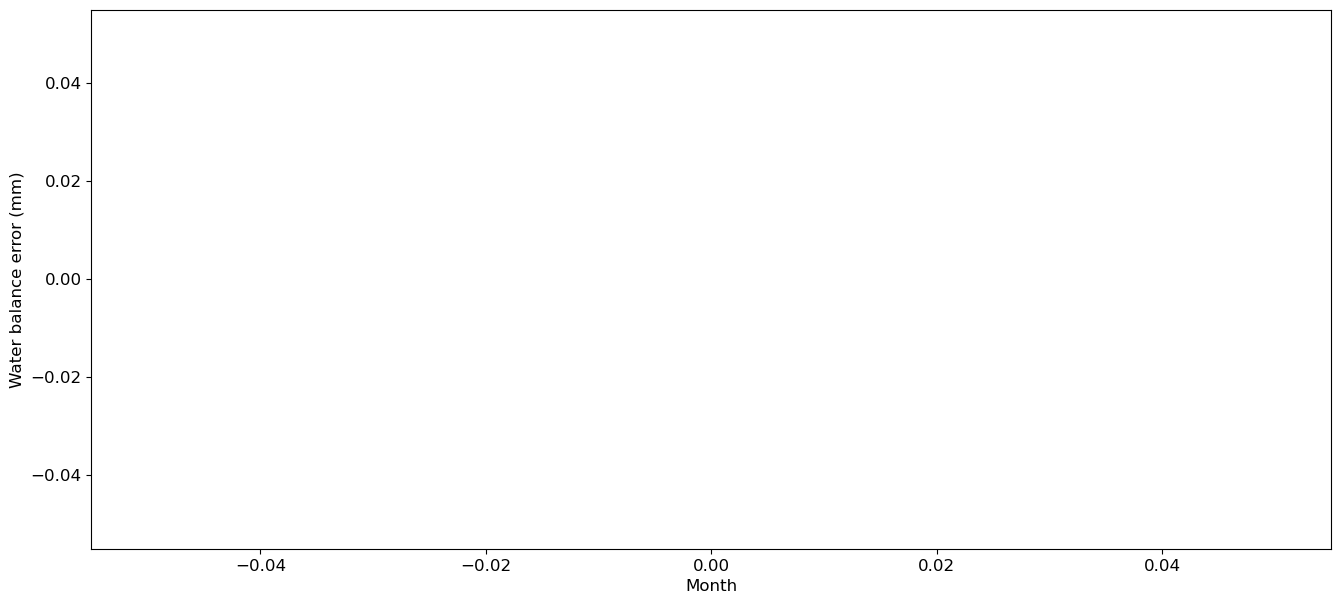

In [87]:
# # Fill the NaN values
mS = mS.fillna(0)
vS = vS.fillna(1e+9)

mPostP, vPostP, mPostE, vPostE, mPostQ, vPostQ, mPostS, vPostS, mPostS0, vPostS0 = close_water_balance(mP, vP, mE, vE, mQ, vQ, mS, vS)

nt = len(mP)
Swb = np.zeros(nt)
for t in range(nt):
    if t == 0:
        Swb[t] = mPostS0 + mPostP[t] - mPostE[t] - mPostQ[t]
    else:
        Swb[t] = Swb[t-1] + mPostP[t] - mPostE[t] - mPostQ[t]
wbError = Swb - mPostS

plt.figure(figsize=(16,7))
plt.plot(wbError)
plt.xlabel('Month')
plt.ylabel('Water balance error (mm)');




Finally, also plot monthly time-series of the posteriors for each variable. For example, this can be done by plotting the posterior mean and uncertainty interval (+-sigma). Adding the original observations to the same plot is also useful.

In [117]:
def PlotPosterior(name, m, v, obs1, obs2, obs3, obs4, l1, l2, l3):
    mu = m
    sigma = np.sqrt(v)
    lower = mu - sigma
    upper = mu + sigma
    plt.figure(figsize=(16,7))
    plt.fill_between(np.arange(len(lower)), lower, upper, color='grey', alpha=0.5)
    plt.plot(mu, 'k')
    plt.plot(np.ma.masked_values(obs1, -99999), 'r.', label=l1)
    plt.plot(np.ma.masked_values(obs2, -99999), 'b.', label=l2)
    plt.plot(np.ma.masked_values(obs3, -99999), 'g.', label=l3)
    plt.plot(np.ma.masked_values(obs4, -99999), 'o.', label=l4)
    plt.ylabel(name)

UFuncTypeError: ufunc 'equal' did not contain a loop with signature matching types (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyLongDType'>) -> None

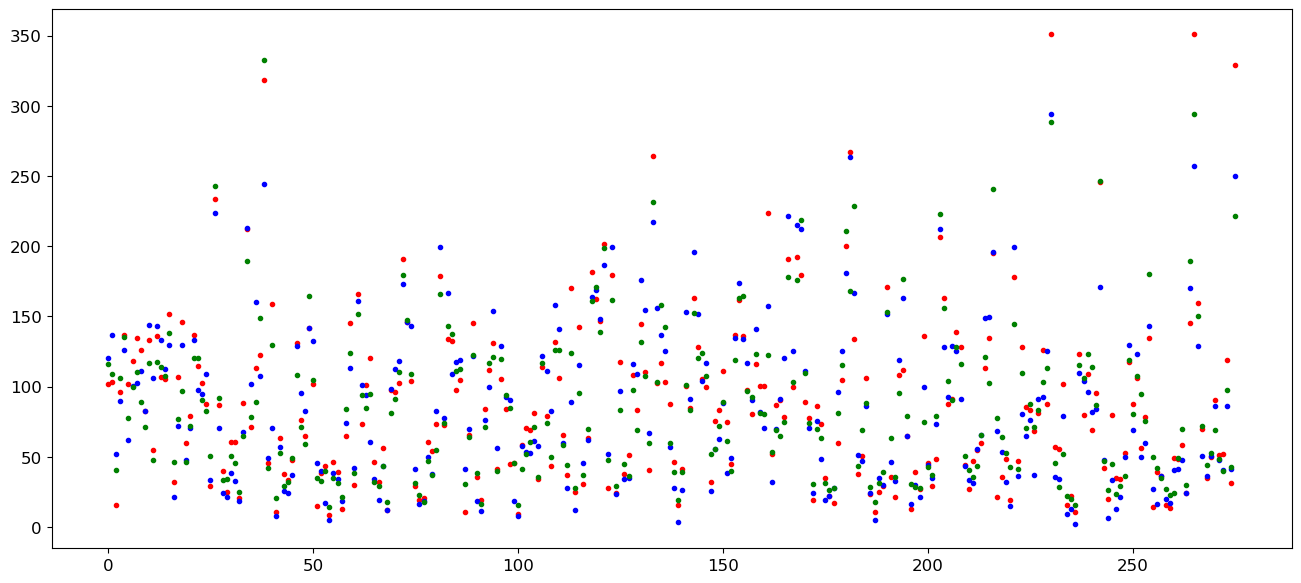

In [119]:
PlotPosterior("P (mm)", mPostP, vPostP, PObs1, PObs2, PObs3, 'imerg', 'era5P', 'chirps', '')
PlotPosterior("E (mm)", mPostE, vPostE, EObs1, EObs2, EObs3, EObs4, 'gldas', 'era5E', 'mod16', 'CMRSET')
PlotPosterior("Q (mm)", mPostQ, vPostQ, QObs, QObs, QObs, QObs, 'GOV', 'GRDC', '','')
PlotPosterior("S (mm)", mPostS, vPostS, SObs, SObs, SObs, SObs, 'SObs', '', '', '')

### Conclusion and further extensions
This completes the notebook!

The final estimated posteriors (and results of data assimilation in general) depend to a great extent on the assumptions that are made about uncertainty in the model and the data (see e.g. assumptions we made in part 1). This is still very much an open research problem. 

For example, a [recent paper](https://doi.org/10.1029/2020WR029071) proposed specific data error models for closing the water balance. The approach used in that paper follows a similar methodology as we used in this notebook, but with additional features:
* Adding non-negativity constraints on the water balance variables to prevent non-physical negative estimates. For this a more sophisticated version of Kalman smoothing is used that involves multiple forward-backward passes over the data (iterative smoothing).
* Using data error models that contain basin-specific parameters, so that each river basin can have its own specific set of data error models. These parameters are then also estimated from the data, together with all water balance variables. 

The complete tool developed in that paper is available at https://github.com/gschoups/BasinWaterBalance. 
